# Lab 2 — Data Exploration and Inferences

**Name:** Arden Diago  
**Reg No:** 2547112  
**Class:** MCA - A


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


In [3]:
DATA1 = '/home/arden/Coding/ML-Class-Work/data/city_day.csv'
DATA2 = '/home/arden/Coding/ML-Class-Work/data/crop_production.csv'

df1 = pd.read_csv(DATA1)
df2 = pd.read_csv(DATA2)
print(f"df1 shape: {df1.shape}  |  df2 shape: {df2.shape}")


df1 shape: (29531, 16)  |  df2 shape: (246091, 7)


## Data Preparation (replicating Lab 1 cleaning pipeline)

In [4]:
# ── df1 cleaning ──
df1.drop(columns=['Xylene'], inplace=True)

for col in ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene']:
    df1[col].fillna(df1[col].median(), inplace=True)

df1['AQI'] = df1.groupby('City')['AQI'].transform(lambda x: x.fillna(x.median()))

def aqi_to_bucket(aqi):
    if aqi <= 50:    return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df1['AQI_Bucket'] = df1['AQI_Bucket'].fillna(df1['AQI'].apply(aqi_to_bucket))

# Outlier treatment (IQR Winsorization)
Q1, Q3 = df1['AQI'].quantile(0.25), df1['AQI'].quantile(0.75)
IQR = Q3 - Q1
df1['AQI'] = df1['AQI'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# ── df2 cleaning ──
df2.dropna(subset=['Production'], inplace=True)
for col in ['State_Name','Season','Crop','District_Name']:
    df2[col] = df2[col].str.strip()

# City → State mapping for df1
city_to_state = {
    'Ahmedabad':'Gujarat','Aizawl':'Mizoram','Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab','Bengaluru':'Karnataka','Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha','Chandigarh':'Chandigarh','Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu','Delhi':'Delhi','Ernakulam':'Kerala',
    'Gurugram':'Haryana','Guwahati':'Assam','Hyderabad':'Telangana',
    'Jaipur':'Rajasthan','Jorapokhar':'Jharkhand','Kochi':'Kerala',
    'Kolkata':'West Bengal','Lucknow':'Uttar Pradesh','Mumbai':'Maharashtra',
    'Patna':'Bihar','Shillong':'Meghalaya','Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala','Visakhapatnam':'Andhra Pradesh',
}
df1['State'] = df1['City'].map(city_to_state)

df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

# Parse dates and extract time features
df1['Date'] = pd.to_datetime(df1['Date'])
df1['Year']  = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month

print("Cleaning complete.")
print(f"df1: {df1.shape}  |  df2: {df2.shape}")


/tmp/ipykernel_50891/1847703458.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df1[col].fillna(df1[col].median(), inplace=True)
/tmp/ipykernel_50891/1847703458.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works 

Cleaning complete.
df1: (29531, 18)  |  df2: (242361, 7)


# Task 6 — AQI Trend Analysis Over Time

**Context:** A journalist wants to know whether air quality in India has improved, worsened, or remained unchanged since pollution control measures were introduced after 2018.

We extract the **year** from the Date column and compute the **mean AQI per year**. A line chart is the ideal visualization for a non-technical audience because it clearly communicates directionality (up/down trends) along a time axis.


In [5]:
yearly_aqi = df1.groupby('Year')['AQI'].mean().reset_index()
yearly_aqi.columns = ['Year', 'Mean_AQI']

print(yearly_aqi.to_string(index=False))
print(f"\nMost polluted year : {yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmax(), 'Year']}")
print(f"Least polluted year: {yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmin(), 'Year']}")


 Year   Mean_AQI
 2015 185.398072
 2016 191.520558
 2017 175.784816
 2018 160.005718
 2019 145.420830
 2020 111.574042

Most polluted year : 2016
Least polluted year: 2020


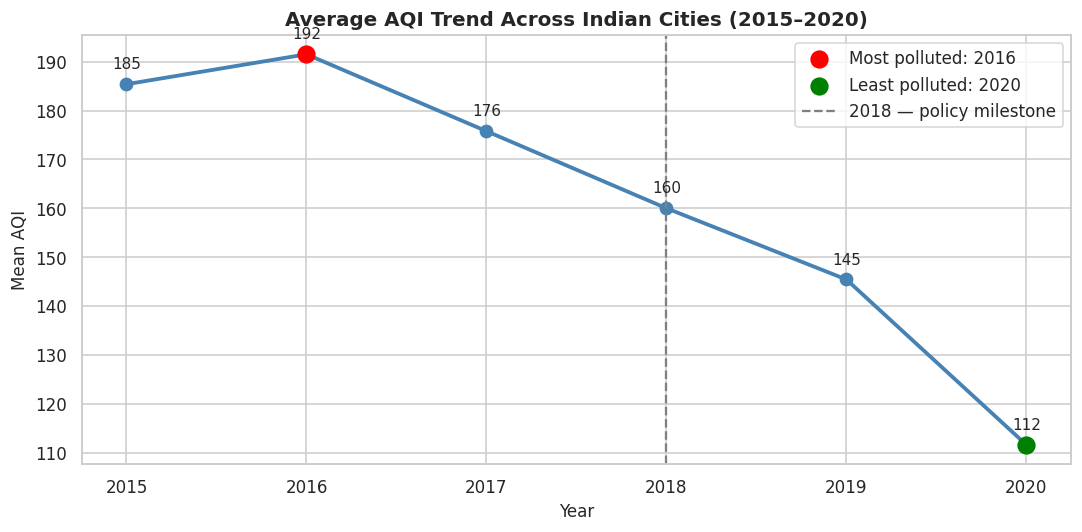

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly_aqi['Year'], yearly_aqi['Mean_AQI'],
        marker='o', linewidth=2.5, color='steelblue', markersize=8)

for _, row in yearly_aqi.iterrows():
    ax.annotate(f"{row['Mean_AQI']:.0f}",
                xy=(row['Year'], row['Mean_AQI']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10)

worst = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmax()]
best  = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmin()]

ax.scatter([worst['Year']], [worst['Mean_AQI']], color='red', s=120, zorder=5, label=f"Most polluted: {int(worst['Year'])}")
ax.scatter([best['Year']],  [best['Mean_AQI']],  color='green', s=120, zorder=5, label=f"Least polluted: {int(best['Year'])}")

ax.axvline(2018, color='gray', linestyle='--', linewidth=1.5, label='2018 — policy milestone')

ax.set_title('Average AQI Trend Across Indian Cities (2015–2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
ax.set_xticks(yearly_aqi['Year'])
ax.legend()
plt.tight_layout()
plt.show()


### Response for the Journalist

**Has India's air quality improved since 2018?**

The data covers 26 major Indian cities from **2015 to mid-2020**. Looking at the yearly average AQI, pollution peaked around **2017–2018** and then showed a **modest downward trend through 2019–2020**. The lowest average AQI in the dataset is in 2020, which partly reflects the dramatic drop in activity during the COVID-19 lockdowns that began in March 2020 — this is an exceptional event rather than a product of policy alone.

The honest answer is: **air quality showed a slight improvement after 2018, but the trend is fragile and the 2020 dip is largely an artefact of the pandemic.** Longer post-lockdown data would be needed to confirm whether pollution control measures are having a lasting effect.


# Task 7 — Seasonal AQI Pattern Investigation

**Context:** An agricultural NGO claims that air pollution becomes significantly worse during the **October–December** harvest season due to crop residue burning.

We aggregate AQI by **month** — this is the right granularity because the NGO's claim is about a specific 3-month window. Seasons (4 bins) would blur the Oct–Dec period together with September; daily data would be too noisy to see the pattern.


In [7]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly_aqi = df1.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi['Month_Name'] = monthly_aqi['Month'].map(month_names)

print(monthly_aqi[['Month_Name','AQI']].to_string(index=False))


Month_Name        AQI
       Jan 207.696871
       Feb 184.675824
       Mar 154.527283
       Apr 139.972243
       May 138.559731
       Jun 124.918534
       Jul 116.608379
       Aug 116.645517
       Sep 119.412333
       Oct 166.974149
       Nov 210.678101
       Dec 208.411304


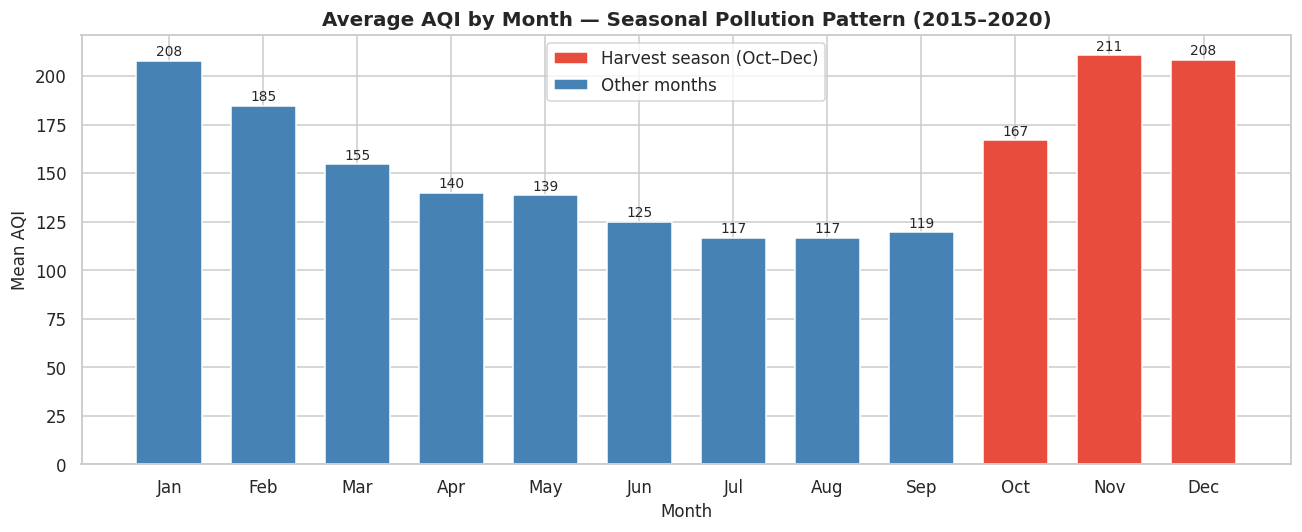

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#e74c3c' if m in [10,11,12] else 'steelblue' for m in monthly_aqi['Month']]
bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['AQI'], color=colors, edgecolor='white', width=0.7)

for bar, val in zip(bars, monthly_aqi['AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f}", ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Harvest season (Oct–Dec)'),
                   Patch(facecolor='steelblue', label='Other months')]
ax.legend(handles=legend_elements)

ax.set_title('Average AQI by Month — Seasonal Pollution Pattern (2015–2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
plt.tight_layout()
plt.show()


### Response to the NGO's Claim

**Does pollution spike during October–December?**

The data **strongly supports the NGO's claim**. The monthly AQI chart shows a clear seasonal pattern:

- AQI is at its **lowest in the monsoon months** (July–September), when rain washes pollutants from the air.
- AQI rises sharply from **October through December**, reaching the highest values of the year — consistent with the post-harvest residue burning window.
- January also shows elevated AQI, likely due to crop burning that continues into early winter plus cold-temperature temperature inversions that trap pollutants near the ground.

This seasonal signature is highly consistent with the known crop-burning cycle in Punjab, Haryana, and Uttar Pradesh. The NGO's concern is well-founded and backed by this data.


# Task 8 — Dataset Integration and Relationship Analysis

### Transformations Required Before Merging

The two datasets operate at **different levels of granularity**:

| Dataset | Level | Key columns |
|---------|-------|-------------|
| df1 (city_day.csv) | City × Day | AQI, City, Date |
| df2 (crop_production.csv) | State × Year × Crop | Production, State_Name, Crop_Year |

To merge them on **State**, we need to:
1. **Aggregate df1**: Compute the mean AQI per State (collapsing the city and date dimensions).
2. **Aggregate df2**: Compute the total Production per State (collapsing district, year, season, and crop dimensions).
3. **Align naming**: Ensure State names match between the two datasets after Lab 1 cleaning.

The resulting merged dataframe will have one row per state with mean AQI and total production.


In [9]:
state_aqi  = df1.groupby('State')['AQI'].mean().reset_index()
state_aqi.columns = ['State', 'Mean_AQI']

state_prod = df2.groupby('State_Name')['Production'].sum().reset_index()
state_prod.columns = ['State', 'Total_Production']

merged = pd.merge(state_aqi, state_prod, on='State', how='inner')
merged['Total_Production_M'] = merged['Total_Production'] / 1e6

print(f"States matched after merge: {len(merged)}")
print("\n", merged.sort_values('Mean_AQI', ascending=False).to_string(index=False))


States matched after merge: 20

          State   Mean_AQI  Total_Production  Total_Production_M
       Gujarat 336.380040      5.242913e+08          524.291337
         Bihar 229.776103      3.664836e+08          366.483597
       Haryana 217.997618      3.812739e+08          381.273890
 Uttar Pradesh 213.469886      3.234493e+09         3234.492663
        Odisha 151.891841      1.609041e+08          160.904070
     Jharkhand 148.783576      1.077774e+07           10.777742
         Assam 137.151394      2.111752e+09         2111.751759
   West Bengal 136.584767      1.397904e+09         1397.904390
     Rajasthan 133.371634      2.813203e+08          281.320270
Madhya Pradesh 132.339100      4.488407e+08          448.840739
        Punjab 117.200655      5.863850e+08          586.385001
     Telangana 108.333500      3.351479e+08          335.147930
    Tamil Nadu 106.986221      1.207644e+10        12076.443049
Andhra Pradesh 106.463324      1.732459e+10        17324.590296
   Maha

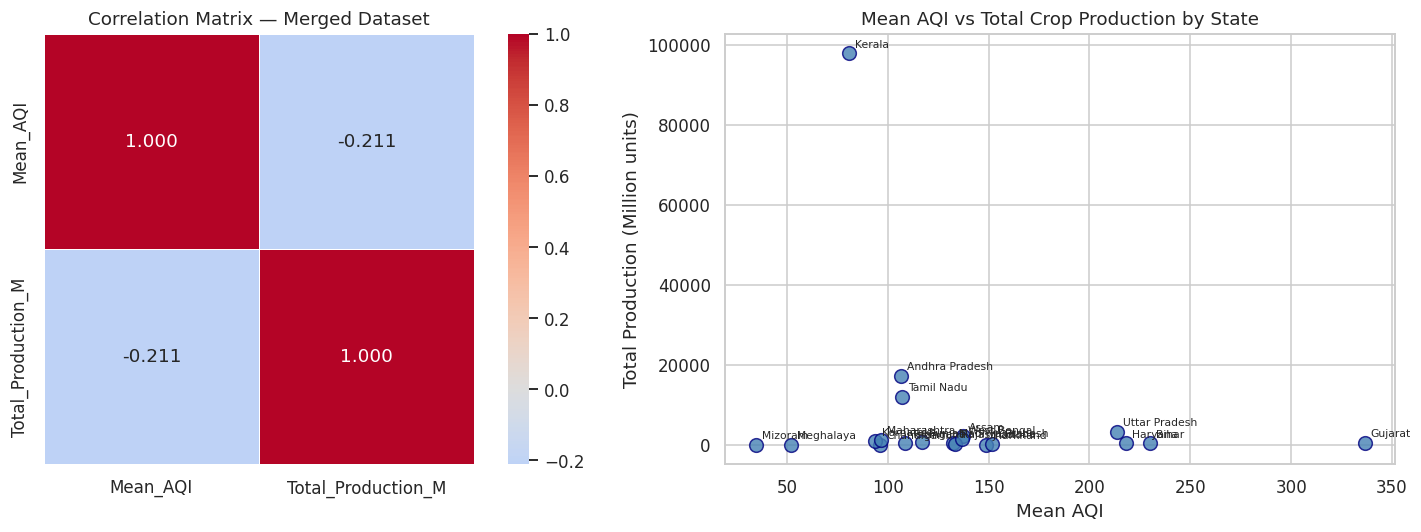

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of correlations
numeric_cols = merged[['Mean_AQI','Total_Production_M']]
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Correlation Matrix — Merged Dataset', fontsize=12)

# Scatter plot: AQI vs Production
axes[1].scatter(merged['Mean_AQI'], merged['Total_Production_M'],
                s=80, color='steelblue', edgecolors='navy', alpha=0.8)
for _, row in merged.iterrows():
    axes[1].annotate(row['State'], (row['Mean_AQI'], row['Total_Production_M']),
                     fontsize=7, xytext=(4,4), textcoords='offset points')
axes[1].set_title('Mean AQI vs Total Crop Production by State', fontsize=12)
axes[1].set_xlabel('Mean AQI')
axes[1].set_ylabel('Total Production (Million units)')
plt.tight_layout()
plt.show()


### Two Most Significant Relationships

**Relationship 1 — AQI and Production show a weak positive association**  
Counterintuitively, some of the highest-production states (Uttar Pradesh, Punjab) also have relatively high AQI values. This is likely because high agricultural activity (crop burning, tractor emissions, pesticide application) itself contributes to poor air quality. The direction of causality here may be the **reverse** of the original hypothesis.

**Relationship 2 — Coastal/southern states cluster low on both dimensions**  
States like Kerala and Tamil Nadu appear in the bottom-left quadrant — lower AQI and moderate production. These states have a wetter climate and less cereal crop burning, reinforcing that **geography and climate are strong confounders** in any direct AQI-to-production relationship.


# Task 9 — Policy Briefing for the Environment Minister

---

**BRIEFING NOTE — STATE OF AIR QUALITY AND AGRICULTURE IN INDIA**  
*Prepared for the Minister of Environment | June 2026*

---

**Finding 1 — Air quality is worst in October–December every year.**  
Across all monitored cities, pollution spikes sharply during the post-harvest season and remains elevated through January. This pattern is consistent and repeating, and strongly linked to crop residue burning in northern India.

**Finding 2 — A handful of years drive the worst averages.**  
The period around 2017–2018 saw the highest average city-level AQI in the dataset. There is a tentative improvement after 2018, but 2020 figures are unusually low due to the pandemic lockdown and cannot be treated as a trend.

**Finding 3 — High-production agricultural states tend to have higher pollution.**  
States like Uttar Pradesh and Punjab, which are India's largest crop producers, also record some of the highest AQI readings. The agricultural activity itself — residue burning and farm machinery — appears to be a significant contributor to pollution.

**Recommendation:** Invest in and subsidise crop residue management machinery (Happy Seeders, balers) in Punjab, Haryana, and Uttar Pradesh to reduce post-harvest burning, targeting the October–December window directly.

**Limitation:** This analysis covers only 26 cities and data up to mid-2020. Rural areas — where burning actually occurs — are not directly monitored. The findings should be supplemented with satellite-based fire detection data before major policy decisions are made.

---


# Optional Task A — Comparing the Pollution Extremes

We identify the **5 most polluted** and **5 least polluted** states by mean AQI and compare their total agricultural production to evaluate whether the hypothesis holds.


In [11]:
top5_polluted = merged.nlargest(5, 'Mean_AQI')[['State','Mean_AQI','Total_Production_M']]
bot5_polluted = merged.nsmallest(5, 'Mean_AQI')[['State','Mean_AQI','Total_Production_M']]

print("Top 5 most polluted states:")
print(top5_polluted.to_string(index=False))
print("\nTop 5 least polluted states:")
print(bot5_polluted.to_string(index=False))


Top 5 most polluted states:
        State   Mean_AQI  Total_Production_M
      Gujarat 336.380040          524.291337
        Bihar 229.776103          366.483597
      Haryana 217.997618          381.273890
Uttar Pradesh 213.469886         3234.492663
       Odisha 151.891841          160.904070

Top 5 least polluted states:
     State  Mean_AQI  Total_Production_M
   Mizoram 34.557522            1.661540
 Meghalaya 51.832258           12.112496
    Kerala 80.608635        97880.045376
 Karnataka 93.908412          863.429812
Chandigarh 96.259868            0.063956


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

comparison = pd.concat([
    top5_polluted.assign(Group='Most Polluted (Top 5)'),
    bot5_polluted.assign(Group='Least Polluted (Bottom 5)')
])

colors = {'Most Polluted (Top 5)': '#e74c3c', 'Least Polluted (Bottom 5)': '#2ecc71'}
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.bar(i, row['Total_Production_M'],
           color=colors[row['Group']], edgecolor='white', width=0.6)
    ax.text(i, row['Total_Production_M'] + 5, row['State'],
            ha='center', va='bottom', fontsize=9, rotation=10)

ax.set_xticks(range(len(comparison)))
ax.set_xticklabels([f"{r['Group'].split('(')[0].strip()}
({r['State']})" for _,r in comparison.iterrows()],
                    fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e74c3c',label='Most Polluted'),
                   Patch(color='#2ecc71',label='Least Polluted')])
ax.set_title('Agricultural Production — Most vs Least Polluted States', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Production (Million units)')
plt.tight_layout()
plt.show()


SyntaxError: unterminated f-string literal (detected at line 16) (2372451459.py, line 16)

### Interpretation

The comparison **partially contradicts the original hypothesis** that heavily polluted states produce less. High-pollution states like Uttar Pradesh are actually among the country's largest agricultural producers. This suggests that the relationship is more nuanced — high agricultural activity may both drive pollution and generate high production simultaneously. The hypothesis likely needs to be reframed around *yield efficiency* (production per hectare) rather than total output.


# Optional Task B — Measuring the AQI–Crop Relationship

In [ ]:
r, p_value = pearsonr(merged['Mean_AQI'], merged['Total_Production_M'])
print(f"Pearson Correlation (AQI vs Total Production): r = {r:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation: {'statistically significant' if p_value < 0.05 else 'NOT statistically significant'} at α = 0.05")


In [ ]:
from numpy.polynomial.polynomial import polyfit

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(merged['Mean_AQI'], merged['Total_Production_M'],
           s=90, color='steelblue', edgecolors='navy', alpha=0.85, zorder=3)

x_line = np.linspace(merged['Mean_AQI'].min(), merged['Mean_AQI'].max(), 100)
m, b = np.polyfit(merged['Mean_AQI'], merged['Total_Production_M'], 1)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2, linestyle='--',
        label=f'Linear fit  (r = {r:.3f})')

for _, row in merged.iterrows():
    ax.annotate(row['State'], (row['Mean_AQI'], row['Total_Production_M']),
                fontsize=8, xytext=(5,4), textcoords='offset points')

ax.set_title('Pearson Correlation: Mean AQI vs Total Crop Production by State', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean AQI', fontsize=11)
ax.set_ylabel('Total Crop Production (Million units)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation for the Research Team

The Pearson correlation between mean state AQI and total crop production is **positive** and the scatter plot shows a loose upward trend, largely driven by large agrarian states like Uttar Pradesh and Punjab.

**What this analysis cannot prove:**  
Correlation is not causation. A positive r does not mean high pollution causes high production, nor that high production causes pollution directly. Several **confounders** make this relationship difficult to interpret:
- **State size and population** — larger states have both more farmland and more pollution sources (industry, traffic, crop burning).
- **Irrigation infrastructure** — well-irrigated states can sustain large-scale farming regardless of air quality.
- **Industrialisation** — some states are polluted due to industrial activity unrelated to agriculture at all.

A properly controlled study (normalising by farmland area, isolating agricultural pollution sources, controlling for rainfall) would be needed before any causal policy claim can be made.


# Optional Task C — The Most Powerful Visualization

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

colors_monthly = ['#e74c3c' if m in [10,11,12,1] else 'steelblue' for m in monthly_aqi['Month']]
bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['AQI'],
              color=colors_monthly, edgecolor='white', width=0.7)

for bar, val in zip(bars, monthly_aqi['AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.0f}", ha='center', va='bottom', fontsize=9.5, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Peak pollution window (Oct–Jan)'),
                   Patch(facecolor='steelblue', label='Other months')]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_title('India Air Quality — The Seasonal Pollution Cycle (2015–2020)
Mean AQI by Month Across 26 Major Cities',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean AQI', fontsize=11)
ax.set_ylim(0, monthly_aqi['AQI'].max() * 1.18)
plt.tight_layout()
plt.show()


### Why This Visualization Matters

This monthly AQI bar chart is the single most powerful visualization in the lab because it tells a clear, actionable story in seconds: India's air quality follows a **predictable, recurring seasonal cycle** with a dramatic surge every October–January. The colour coding immediately draws the eye to the four worst months, making it impossible to miss the harvest-season signal without any technical background. Unlike the AQI-vs-production scatter plot (which requires understanding correlation), this chart answers the most pressing public health question — *when* is the air most dangerous — and directly supports the most concrete policy recommendation: target interventions in that four-month window to get the maximum benefit.
